# Attention Mechanism Comparison: MHA vs MQA vs GQA

Comprehensive evaluation comparing Multi-Head Attention (MHA), Multi-Query Attention (MQA), and Grouped Query Attention (GQA) models trained on TinyStories.

**Metrics:**
- Perplexity on test set
- Inference speed (tokens/sec) at different sequence lengths
- KV-cache memory size
- Generation quality: Distinct-1/2/3, Repetition rate
- Top-k accuracy (k=1, 5, 10)
- Attention entropy per layer

**Models:**
- MHA: 8 query heads, 8 KV heads (baseline)
- MQA: 8 query heads, 1 KV head
- GQA-4: 8 query heads, 4 KV heads

**Setup:**
1. Runtime -> Change runtime type -> GPU (L4/T4)
2. Upload model checkpoints to `/content/models/` or Google Drive
3. Run all cells

## 1. Setup & Installation

In [1]:
# Check GPU
!nvidia-smi

import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"BFloat16 supported: {torch.cuda.is_bf16_supported()}")

Fri Nov 28 00:16:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   37C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install dependencies
!pip install -q transformers datasets tqdm tensorboard matplotlib

print("Dependencies installed")

Dependencies installed


In [3]:
# Clone repository
import os

if os.path.exists('PROJECT'):
    !rm -rf PROJECT
    print("Existing repository removed")

!git clone https://gitlab.cim.rhul.ac.uk/wmis066/PROJECT.git
print("Repository cloned")

%cd PROJECT

Cloning into 'PROJECT'...
remote: Enumerating objects: 2085, done.
remote: Counting objects: 100% (2082/2082), done.
remote: Compressing objects: 100% (483/483), done.
remote: Total 2085 (delta 1656), reused 1877 (delta 1573), pack-reused 3 (from 1)
Receiving objects: 100% (2085/2085), 14.43 MiB | 2.76 MiB/s, done.
Resolving deltas: 100% (1656/1656), done.
Repository cloned
/content/PROJECT


In [4]:
import sys
import importlib
import shutil

# Clear Python cache
print("Clearing Python cache...")

modules_to_remove = [m for m in list(sys.modules.keys())
                     if any(x in m for x in ['gqa', 'mha', 'mqa', 'train', 'transformer', 'data_loader', 'attention', 'layers'])]
for module in modules_to_remove:
    del sys.modules[module]
print(f"Removed {len(modules_to_remove)} cached modules")

# Clear __pycache__ directories
cache_dirs = [
    '/content/PROJECT/AttentionHeads/gqa/__pycache__',
    '/content/PROJECT/AttentionHeads/mha/__pycache__',
    '/content/PROJECT/AttentionHeads/mqa/__pycache__',
    '/content/PROJECT/AttentionHeads/__pycache__',
]
for cache_dir in cache_dirs:
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"Cleared {cache_dir}")

# Add to path
project_root = '/content/PROJECT'
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added {project_root} to sys.path")

Clearing Python cache...
Removed 8 cached modules
Added /content/PROJECT to sys.path


In [5]:
# Import modules
import torch
import torch.nn.functional as F
import numpy as np
import json
import time
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

from AttentionHeads.mha.transformer import create_gptneo_model as create_mha_model
from AttentionHeads.mqa.transformer import create_gptneo_model as create_mqa_model
from AttentionHeads.gqa.transformer import create_gptneo_model as create_gqa_model
from AttentionHeads.mha.data_loader import TinyStoriesDataModule
from transformers import GPT2Tokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print("Modules imported successfully")

Device: cuda
Modules imported successfully


## 2. Upload Models

**Option A:** Upload directly to Colab
- Create `/content/models/` folder
- Upload `best_model_mha.pt`, `best_model_mqa.pt`, `best_model_gqa4.pt`

**Option B:** Load from Google Drive
- Mount Drive and update `MODELS_DIR` path below

In [6]:
# Create models directory
!mkdir -p /content/models

# Option: Mount Google Drive (uncomment if using Drive)
# from google.colab import drive
# drive.mount('/content/drive')

print("Upload your model checkpoints to /content/models/")
print("Required files:")
print("  - best_model_mha.pt")
print("  - best_model_mqa.pt")
print("  - best_model_gqa4.pt")

Upload your model checkpoints to /content/models/
Required files:
  - best_model_mha.pt
  - best_model_mqa.pt
  - best_model_gqa4.pt


## 3. Configuration

In [7]:
# Model configurations (must match training)
base_config = {
    'vocab_size': 50257,
    'hidden_size': 256,
    'num_layers': 4,
    'num_heads': 8,
    'intermediate_size': 1024,
    'max_position_embeddings': 256,
    'dropout': 0.0
}

model_configs = {
    'MHA': {**base_config, 'num_kv_heads': 8},
    'MQA': {**base_config, 'num_kv_heads': 1},
    'GQA-4': {**base_config, 'num_kv_heads': 4}
}

# Checkpoint paths - UPDATE THIS if using Google Drive
MODELS_DIR = '/content/models'
# MODELS_DIR = '/content/drive/MyDrive/your_models_folder'  # For Google Drive

checkpoint_paths = {
    'MHA': f'{MODELS_DIR}/best_model_mha.pt',
    'MQA': f'{MODELS_DIR}/best_model_mqa.pt',
    'GQA-4': f'{MODELS_DIR}/best_model_gqa4.pt'
}

# Evaluation settings
eval_config = {
    'test_samples': 2000,
    'batch_size': 32,
    'seq_lengths': [64, 128, 256],
    'generation_samples': 100,
    'generation_max_length': 100
}

# Generation prompts
prompts = [
    "Once upon a time",
    "One day, a little girl",
    "In a big forest",
    "There was a happy dog",
    "A small boy found"
]

# Output directory
OUTPUT_DIR = '/content/evaluation_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/charts', exist_ok=True)

print("Configuration set")
print(f"Models directory: {MODELS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Configuration set
Models directory: /content/models
Output directory: /content/evaluation_results


## 4. Load Models

In [8]:
def load_model(name, config, checkpoint_path):
    """Load a model from checkpoint"""
    if name == 'MHA':
        model = create_mha_model(config)
    elif name == 'MQA':
        model = create_mqa_model(config)
    else:
        model = create_gqa_model(config)

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    model.to(device)
    model.eval()

    return model, checkpoint

# Verify checkpoints exist
print("Checking for model checkpoints...")
for name, path in checkpoint_paths.items():
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  {name}: {path} [{status}]")
    if not exists:
        print(f"    -> Please upload {os.path.basename(path)} to {MODELS_DIR}/")

Checking for model checkpoints...
  MHA: /content/models/best_model_mha.pt [OK]
  MQA: /content/models/best_model_mqa.pt [OK]
  GQA-4: /content/models/best_model_gqa4.pt [OK]


In [9]:
# Load all models
models = {}
checkpoints = {}

for name in ['MHA', 'MQA', 'GQA-4']:
    print(f"Loading {name}...")
    models[name], checkpoints[name] = load_model(
        name, model_configs[name], checkpoint_paths[name]
    )
    params = models[name].get_num_params()
    print(f"  Parameters: {params:,}")
    if 'best_val_loss' in checkpoints[name]:
        print(f"  Best val loss: {checkpoints[name]['best_val_loss']:.4f}")

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

print("\nAll models loaded successfully!")

Loading MHA...
  Parameters: 16,090,880
  Best val loss: 3.6065
Loading MQA...
  Parameters: 15,630,336
  Best val loss: 3.6065
Loading GQA-4...
  Parameters: 15,827,712
  Best val loss: 3.6065


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]


All models loaded successfully!


## 5. Load Test Data

In [10]:
data_config = {
    'dataset_name': 'roneneldan/TinyStories',
    'tokenizer': 'gpt2',
    'train_samples': 1000,
    'val_samples': eval_config['test_samples'],
    'batch_size': eval_config['batch_size'],
    'max_seq_length': 256,
    'num_workers': 2,
    'pin_memory': True
}

data_module = TinyStoriesDataModule(data_config)
data_module.setup()
test_loader = data_module.val_dataloader()

print(f"Test samples: {eval_config['test_samples']}")
print(f"Batch size: {eval_config['batch_size']}")


Setting up TinyStories datasets...
Loading TinyStories dataset (split=train)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Sampling 1000 from 2119719 examples...
Dataset size: 1000
Loading TinyStories dataset (split=validation)...
Sampling 2000 from 21990 examples...
Dataset size: 2000

Dataset Summary:
  Train samples: 1,000
  Val samples: 2,000
  Max sequence length: 256
  Batch size: 32
  Vocab size: 50257

Test samples: 2000
Batch size: 32


## 6. Metric Functions

In [11]:
def compute_perplexity(model, dataloader, max_batches=None):
    """Compute perplexity on dataset"""
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Computing PPL")):
            if max_batches and i >= max_batches:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(input_ids)

            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = input_ids[:, 1:].contiguous()
            shift_mask = attention_mask[:, 1:].contiguous()

            loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                reduction='none'
            )
            loss = loss.view(shift_labels.size())

            masked_loss = (loss * shift_mask).sum()
            num_tokens = shift_mask.sum()

            total_loss += masked_loss.item()
            total_tokens += num_tokens.item()

    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

In [12]:
def compute_inference_speed(model, seq_length, batch_size=1, num_runs=50):
    """Measure inference speed in tokens/sec"""
    model.eval()
    input_ids = torch.randint(0, 50257, (batch_size, seq_length)).to(device)

    # Warmup
    for _ in range(5):
        with torch.no_grad():
            _ = model(input_ids)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(input_ids)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()

    total_tokens = batch_size * seq_length * num_runs
    tokens_per_sec = total_tokens / (end - start)
    return tokens_per_sec


def compute_kv_cache_size(config, seq_length, batch_size=1, dtype_bytes=2):
    """Calculate theoretical KV-cache size in MB"""
    num_layers = config['num_layers']
    num_kv_heads = config.get('num_kv_heads', config['num_heads'])
    head_dim = config['hidden_size'] // config['num_heads']

    cache_elements = 2 * num_layers * num_kv_heads * head_dim * seq_length * batch_size
    cache_bytes = cache_elements * dtype_bytes
    cache_mb = cache_bytes / (1024 * 1024)
    return cache_mb

In [13]:
def compute_distinct_n(texts, n):
    """Compute distinct-n: unique n-grams / total n-grams"""
    all_ngrams = []
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)

    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


def compute_repetition_rate(texts, n=3):
    """Compute repetition rate: fraction of repeated n-grams"""
    total_ngrams = 0
    repeated_ngrams = 0

    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        counts = Counter(ngrams)

        total_ngrams += len(ngrams)
        repeated_ngrams += sum(c - 1 for c in counts.values() if c > 1)

    if total_ngrams == 0:
        return 0.0
    return repeated_ngrams / total_ngrams

In [14]:
def compute_topk_accuracy(model, dataloader, k_values=[1, 5, 10], max_batches=None):
    """Compute top-k accuracy for next token prediction"""
    model.eval()
    correct = {k: 0 for k in k_values}
    total = 0

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Computing Top-k")):
            if max_batches and i >= max_batches:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(input_ids)

            shift_logits = logits[:, :-1, :]
            shift_labels = input_ids[:, 1:]
            shift_mask = attention_mask[:, 1:]

            for k in k_values:
                _, topk_preds = torch.topk(shift_logits, k, dim=-1)
                matches = (topk_preds == shift_labels.unsqueeze(-1)).any(dim=-1)
                correct[k] += (matches * shift_mask).sum().item()

            total += shift_mask.sum().item()

    return {k: correct[k] / total for k in k_values}

In [15]:
def compute_attention_entropy(model, dataloader, max_batches=5):
    """Compute average attention entropy per layer"""
    model.eval()
    attention_weights = {}

    def hook_fn(name):
        def hook(module, input, output):
            if isinstance(output, tuple) and len(output) > 1:
                attn = output[1]
                if attn is not None:
                    attention_weights[name] = attn.detach()
        return hook

    hooks = []
    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'attn'):
            h = layer.attn.register_forward_hook(hook_fn(f'layer_{i}'))
            hooks.append(h)

    all_entropies = {f'layer_{i}': [] for i in range(len(model.layers))}

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= max_batches:
                break

            input_ids = batch['input_ids'].to(device)
            _ = model(input_ids)

            for name, attn in attention_weights.items():
                attn = attn + 1e-10
                entropy = -torch.sum(attn * torch.log(attn), dim=-1)
                all_entropies[name].append(entropy.mean().item())

    for h in hooks:
        h.remove()

    return {name: np.mean(vals) if vals else 0.0 for name, vals in all_entropies.items()}

In [16]:
def generate_texts(model, tokenizer, prompts, num_per_prompt=20, max_length=100):
    """Generate texts from prompts"""
    model.eval()
    generated = []

    for prompt in prompts:
        for _ in range(num_per_prompt):
            input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

            with torch.no_grad():
                output_ids = model.generate(
                    input_ids,
                    max_length=max_length,
                    temperature=0.8,
                    top_k=50,
                    top_p=0.95
                )

            text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
            generated.append(text)

    return generated

## 7. Run Evaluation

In [17]:
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating {name}")
    print('='*60)

    results[name] = {'config': model_configs[name]}

    # Perplexity
    print("\nComputing perplexity...")
    ppl, loss = compute_perplexity(model, test_loader)
    results[name]['perplexity'] = ppl
    results[name]['loss'] = loss
    print(f"  Perplexity: {ppl:.2f}")

    # Inference speed
    print("\nMeasuring inference speed...")
    results[name]['speed'] = {}
    for seq_len in eval_config['seq_lengths']:
        speed = compute_inference_speed(model, seq_len)
        results[name]['speed'][seq_len] = speed
        print(f"  Seq {seq_len}: {speed:,.0f} tokens/sec")

    # KV-cache size
    print("\nComputing KV-cache size...")
    results[name]['kv_cache'] = {}
    for seq_len in eval_config['seq_lengths']:
        cache_mb = compute_kv_cache_size(model_configs[name], seq_len)
        results[name]['kv_cache'][seq_len] = cache_mb
        print(f"  Seq {seq_len}: {cache_mb:.3f} MB")

    # Top-k accuracy
    print("\nComputing top-k accuracy...")
    topk = compute_topk_accuracy(model, test_loader, max_batches=30)
    results[name]['topk_accuracy'] = topk
    for k, acc in topk.items():
        print(f"  Top-{k}: {acc*100:.2f}%")

    # Generation quality
    print("\nGenerating texts for quality metrics...")
    texts = generate_texts(model, tokenizer, prompts, num_per_prompt=20)
    results[name]['generated_texts'] = texts[:10]

    distinct1 = compute_distinct_n(texts, 1)
    distinct2 = compute_distinct_n(texts, 2)
    distinct3 = compute_distinct_n(texts, 3)
    rep_rate = compute_repetition_rate(texts)

    results[name]['distinct'] = {'1': distinct1, '2': distinct2, '3': distinct3}
    results[name]['repetition_rate'] = rep_rate
    print(f"  Distinct-1: {distinct1:.4f}")
    print(f"  Distinct-2: {distinct2:.4f}")
    print(f"  Distinct-3: {distinct3:.4f}")
    print(f"  Repetition rate: {rep_rate:.4f}")

    # Attention entropy
    print("\nComputing attention entropy...")
    try:
        entropy = compute_attention_entropy(model, test_loader)
        results[name]['attention_entropy'] = entropy
        for layer, ent in entropy.items():
            print(f"  {layer}: {ent:.4f}")
    except Exception as e:
        print(f"  Could not compute attention entropy: {e}")
        results[name]['attention_entropy'] = {}

print("\n" + "="*60)
print("Evaluation complete!")
print("="*60)


Evaluating MHA

Computing perplexity...


Computing PPL: 100%|██████████| 63/63 [00:05<00:00, 11.81it/s]


  Perplexity: 119.77

Measuring inference speed...
  Seq 64: 15,302 tokens/sec
  Seq 128: 30,226 tokens/sec
  Seq 256: 58,002 tokens/sec

Computing KV-cache size...
  Seq 64: 0.250 MB
  Seq 128: 0.500 MB
  Seq 256: 1.000 MB

Computing top-k accuracy...


Computing Top-k:  48%|████▊     | 30/63 [00:05<00:06,  5.05it/s]


  Top-1: 25.62%
  Top-5: 47.74%
  Top-10: 57.10%

Generating texts for quality metrics...
  Distinct-1: 0.0602
  Distinct-2: 0.3150
  Distinct-3: 0.6235
  Repetition rate: 0.0164

Computing attention entropy...
  Could not compute attention entropy: 'GPTNeoForCausalLM' object has no attribute 'layers'

Evaluating MQA

Computing perplexity...


...

  Top-1: 15.25%
  Top-5: 34.21%
  Top-10: 44.81%

Generating texts for quality metrics...
  Distinct-1: 0.0337
  Distinct-2: 0.2177
  Distinct-3: 0.5297
  Repetition rate: 0.0337

Computing attention entropy...
  Could not compute attention entropy: 'GPTNeoForCausalLM' object has no attribute 'layers'

Evaluating GQA-4

Computing perplexity...


Computing PPL: 100%|██████████| 63/63 [00:04<00:00, 13.23it/s]


  Perplexity: 207.56

Measuring inference speed...
  Seq 64: 14,729 tokens/sec
  Seq 128: 28,752 tokens/sec
  Seq 256: 54,519 tokens/sec

Computing KV-cache size...
  Seq 64: 0.125 MB
  Seq 128: 0.250 MB
  Seq 256: 0.500 MB

Computing top-k accuracy...


Computing Top-k:  48%|████▊     | 30/63 [00:05<00:06,  5.01it/s]


  Top-1: 19.01%
  Top-5: 40.74%
  Top-10: 49.98%

Generating texts for quality metrics...
  Distinct-1: 0.0859
  Distinct-2: 0.4492
  Distinct-3: 0.7729
  Repetition rate: 0.0066

Computing attention entropy...
  Could not compute attention entropy: 'GPTNeoForCausalLM' object has no attribute 'layers'

Evaluation complete!


## 8. Comparison Table

In [18]:
def print_comparison_table(results):
    """Print formatted comparison table with % diff vs MHA"""
    mha = results['MHA']

    def pct_diff(val, baseline):
        if baseline == 0:
            return 0
        return ((val - baseline) / baseline) * 100

    print("\n" + "="*90)
    print("COMPARISON TABLE (% difference vs MHA baseline)")
    print("="*90)
    print(f"{'Metric':<30} {'MHA':<15} {'MQA':<20} {'GQA-4':<20}")
    print("-"*90)

    # Perplexity
    print(f"{'Perplexity':<30} {mha['perplexity']:<15.2f} "
          f"{results['MQA']['perplexity']:.2f} ({pct_diff(results['MQA']['perplexity'], mha['perplexity']):+.1f}%)   "
          f"{results['GQA-4']['perplexity']:.2f} ({pct_diff(results['GQA-4']['perplexity'], mha['perplexity']):+.1f}%)")

    # Top-k accuracy
    for k in [1, 5, 10]:
        print(f"{'Top-'+str(k)+' Accuracy (%)':<30} {mha['topk_accuracy'][k]*100:<15.2f} "
              f"{results['MQA']['topk_accuracy'][k]*100:.2f} ({pct_diff(results['MQA']['topk_accuracy'][k], mha['topk_accuracy'][k]):+.1f}%)   "
              f"{results['GQA-4']['topk_accuracy'][k]*100:.2f} ({pct_diff(results['GQA-4']['topk_accuracy'][k], mha['topk_accuracy'][k]):+.1f}%)")

    # Speed at seq 256
    seq = 256
    print(f"{'Speed @256 (tok/s)':<30} {mha['speed'][seq]:<15,.0f} "
          f"{results['MQA']['speed'][seq]:,.0f} ({pct_diff(results['MQA']['speed'][seq], mha['speed'][seq]):+.1f}%)   "
          f"{results['GQA-4']['speed'][seq]:,.0f} ({pct_diff(results['GQA-4']['speed'][seq], mha['speed'][seq]):+.1f}%)")

    # KV-cache
    print(f"{'KV-Cache @256 (MB)':<30} {mha['kv_cache'][seq]:<15.3f} "
          f"{results['MQA']['kv_cache'][seq]:.3f} ({pct_diff(results['MQA']['kv_cache'][seq], mha['kv_cache'][seq]):+.1f}%)   "
          f"{results['GQA-4']['kv_cache'][seq]:.3f} ({pct_diff(results['GQA-4']['kv_cache'][seq], mha['kv_cache'][seq]):+.1f}%)")

    # Distinct-n
    for n in ['1', '2', '3']:
        print(f"{'Distinct-'+n:<30} {mha['distinct'][n]:<15.4f} "
              f"{results['MQA']['distinct'][n]:.4f} ({pct_diff(results['MQA']['distinct'][n], mha['distinct'][n]):+.1f}%)   "
              f"{results['GQA-4']['distinct'][n]:.4f} ({pct_diff(results['GQA-4']['distinct'][n], mha['distinct'][n]):+.1f}%)")

    # Repetition rate
    print(f"{'Repetition Rate':<30} {mha['repetition_rate']:<15.4f} "
          f"{results['MQA']['repetition_rate']:.4f} ({pct_diff(results['MQA']['repetition_rate'], mha['repetition_rate']):+.1f}%)   "
          f"{results['GQA-4']['repetition_rate']:.4f} ({pct_diff(results['GQA-4']['repetition_rate'], mha['repetition_rate']):+.1f}%)")

    print("="*90)

print_comparison_table(results)


COMPARISON TABLE (% difference vs MHA baseline)
Metric                         MHA             MQA                  GQA-4               
------------------------------------------------------------------------------------------
Perplexity                     119.77          260.82 (+117.8%)   207.56 (+73.3%)
Top-1 Accuracy (%)             25.62           15.25 (-40.5%)   19.01 (-25.8%)
Top-5 Accuracy (%)             47.74           34.21 (-28.4%)   40.74 (-14.7%)
Top-10 Accuracy (%)            57.10           44.81 (-21.5%)   49.98 (-12.5%)
Speed @256 (tok/s)             58,002          57,591 (-0.7%)   54,519 (-6.0%)
KV-Cache @256 (MB)             1.000           0.125 (-87.5%)   0.500 (-50.0%)
Distinct-1                     0.0602          0.0337 (-44.0%)   0.0859 (+42.6%)
Distinct-2                     0.3150          0.2177 (-30.9%)   0.4492 (+42.6%)
Distinct-3                     0.6235          0.5297 (-15.0%)   0.7729 (+24.0%)
Repetition Rate                0.0164          0.03

## 9. Visualization

/tmp/ipython-input-3565860153.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


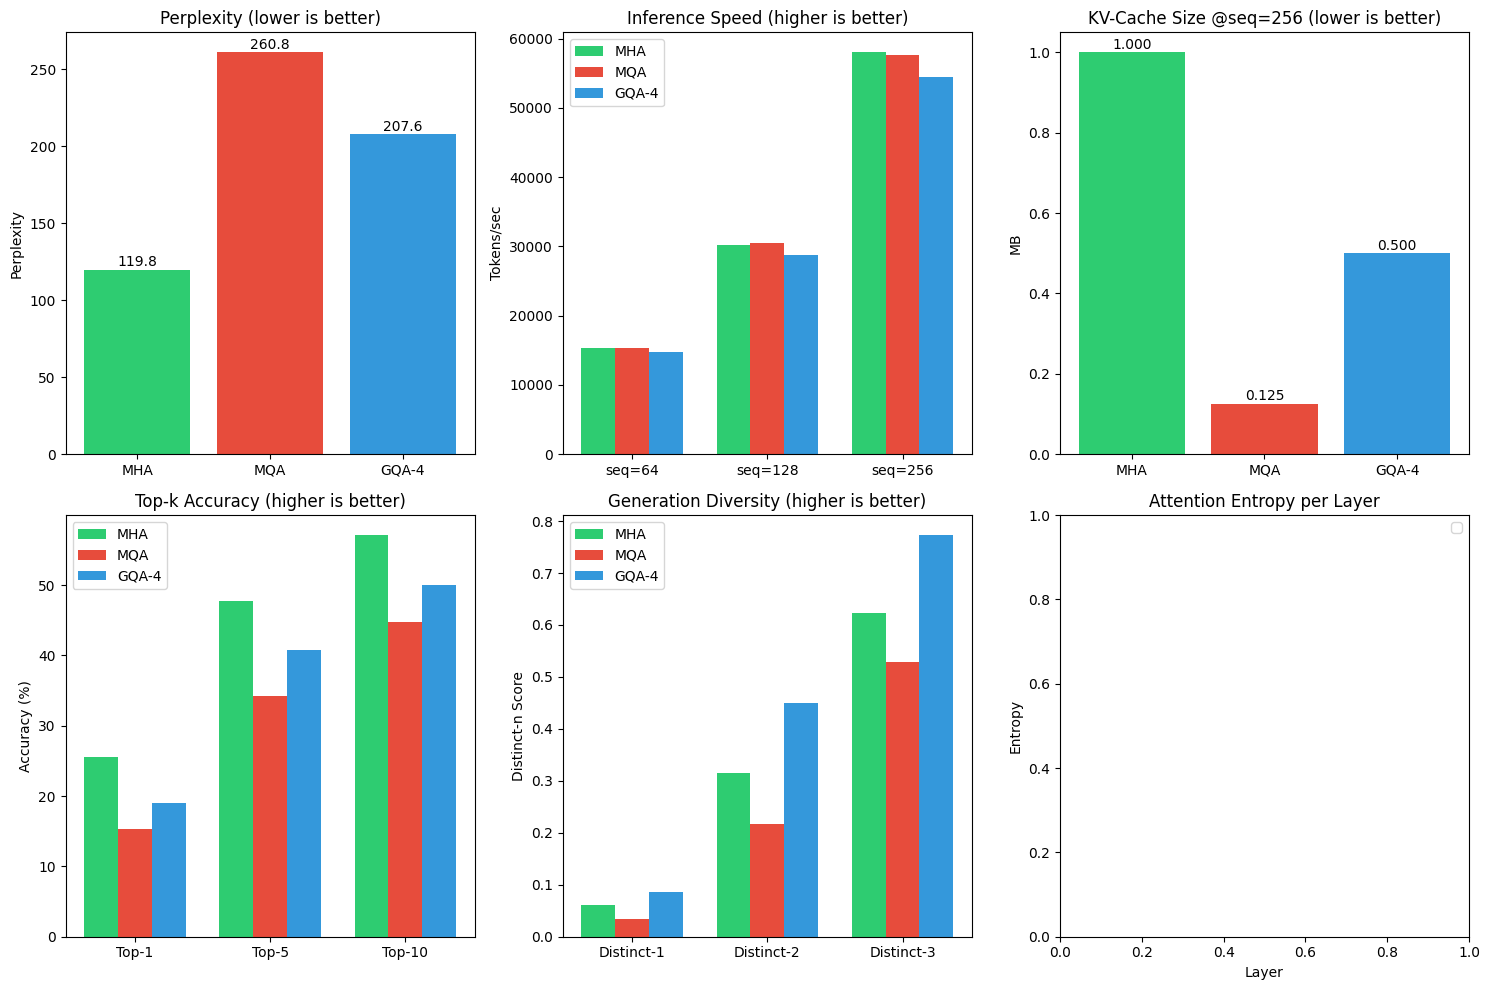

Charts saved to /content/evaluation_results/charts/comparison_metrics.png


In [19]:
model_names = ['MHA', 'MQA', 'GQA-4']
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Perplexity
ax = axes[0, 0]
ppls = [results[m]['perplexity'] for m in model_names]
bars = ax.bar(model_names, ppls, color=colors)
ax.set_ylabel('Perplexity')
ax.set_title('Perplexity (lower is better)')
for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{ppl:.1f}', ha='center', va='bottom')

# 2. Inference Speed
ax = axes[0, 1]
x = np.arange(len(eval_config['seq_lengths']))
width = 0.25
for i, m in enumerate(model_names):
    speeds = [results[m]['speed'][s] for s in eval_config['seq_lengths']]
    ax.bar(x + i*width, speeds, width, label=m, color=colors[i])
ax.set_ylabel('Tokens/sec')
ax.set_title('Inference Speed (higher is better)')
ax.set_xticks(x + width)
ax.set_xticklabels([f'seq={s}' for s in eval_config['seq_lengths']])
ax.legend()

# 3. KV-Cache Size
ax = axes[0, 2]
cache_256 = [results[m]['kv_cache'][256] for m in model_names]
bars = ax.bar(model_names, cache_256, color=colors)
ax.set_ylabel('MB')
ax.set_title('KV-Cache Size @seq=256 (lower is better)')
for bar, c in zip(bars, cache_256):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{c:.3f}', ha='center', va='bottom')

# 4. Top-k Accuracy
ax = axes[1, 0]
x = np.arange(3)
for i, m in enumerate(model_names):
    accs = [results[m]['topk_accuracy'][k]*100 for k in [1, 5, 10]]
    ax.bar(x + i*width, accs, width, label=m, color=colors[i])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Top-k Accuracy (higher is better)')
ax.set_xticks(x + width)
ax.set_xticklabels(['Top-1', 'Top-5', 'Top-10'])
ax.legend()

# 5. Distinct-n
ax = axes[1, 1]
for i, m in enumerate(model_names):
    dist = [results[m]['distinct'][n] for n in ['1', '2', '3']]
    ax.bar(x + i*width, dist, width, label=m, color=colors[i])
ax.set_ylabel('Distinct-n Score')
ax.set_title('Generation Diversity (higher is better)')
ax.set_xticks(x + width)
ax.set_xticklabels(['Distinct-1', 'Distinct-2', 'Distinct-3'])
ax.legend()

# 6. Attention Entropy
ax = axes[1, 2]
for i, m in enumerate(model_names):
    if results[m]['attention_entropy']:
        entropies = list(results[m]['attention_entropy'].values())
        layers = list(range(len(entropies)))
        ax.plot(layers, entropies, 'o-', label=m, color=colors[i])
ax.set_xlabel('Layer')
ax.set_ylabel('Entropy')
ax.set_title('Attention Entropy per Layer')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/charts/comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Charts saved to {OUTPUT_DIR}/charts/comparison_metrics.png")

## 10. Sample Generations

In [20]:
print("\nSample Generations from Each Model")
print("="*90)

sample_generations = {}

for prompt in prompts:
    print(f"\nPrompt: \"{prompt}\"")
    print("-"*90)

    sample_generations[prompt] = {}

    for name, model in models.items():
        input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
        with torch.no_grad():
            output_ids = model.generate(
                input_ids, max_length=100, temperature=0.8, top_k=50, top_p=0.95
            )
        text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        sample_generations[prompt][name] = text
        print(f"\n[{name}]: {text}")

# Save to file
with open(f'{OUTPUT_DIR}/sample_generations.txt', 'w') as f:
    for prompt, gens in sample_generations.items():
        f.write(f"Prompt: {prompt}\n")
        f.write("="*80 + "\n")
        for name, text in gens.items():
            f.write(f"\n[{name}]:\n{text}\n")
        f.write("\n" + "-"*80 + "\n\n")

print(f"\n\nSample generations saved to {OUTPUT_DIR}/sample_generations.txt")


Sample Generations from Each Model

Prompt: "Once upon a time"
------------------------------------------------------------------------------------------

[MHA]: Once upon a time, there was a little girl named Lily. One day, they found a big little girl named Timmy was an big mommy.
One day, so happy. It said, "You'm she loved to make her mom was so happy and smiled and could do the girl and's mommy's mom, Timmy, but they had her mommy had a long.



The next day, "You's mommy and had a big other friends.

[MQA]: Once upon a time to be a big old in a great mom's a big mommy were very not like a good friend said not play in the little girl went to take a so happy that had a big boy decided to have a proud so happy a big a very happy to play her mommy was so happy to play a big mommy took a big big mommy wanted to see a mommy said so find a lot, she wanted to play to play in it had a happy to have

[GQA-4]: Once upon a time, she was very sad, "That. They wanted to play.


But, "Hi, "Let

## 11. Export Results

In [21]:
# Prepare export data
export_results = {}

for name in model_names:
    export_results[name] = {
        'perplexity': results[name]['perplexity'],
        'loss': results[name]['loss'],
        'topk_accuracy': results[name]['topk_accuracy'],
        'speed': results[name]['speed'],
        'kv_cache_mb': results[name]['kv_cache'],
        'distinct': results[name]['distinct'],
        'repetition_rate': results[name]['repetition_rate'],
        'attention_entropy': results[name]['attention_entropy'],
        'num_kv_heads': model_configs[name]['num_kv_heads']
    }

# Add comparison vs MHA
mha_ppl = results['MHA']['perplexity']
for name in ['MQA', 'GQA-4']:
    export_results[name]['ppl_diff_vs_mha'] = (
        (results[name]['perplexity'] - mha_ppl) / mha_ppl * 100
    )

# Save to JSON
json_path = f'{OUTPUT_DIR}/evaluation_results.json'
with open(json_path, 'w') as f:
    json.dump(export_results, f, indent=2)

print(f"Results exported to {json_path}")
print("\nExport summary:")
print(json.dumps(export_results, indent=2))

Results exported to /content/evaluation_results/evaluation_results.json

Export summary:
{
  "MHA": {
    "perplexity": 119.76563963975563,
    "loss": 4.785536830182942,
    "topk_accuracy": {
      "1": 0.25622191026519975,
      "5": 0.4774411543860795,
      "10": 0.5709575266886487
    },
    "speed": {
      "64": 15302.059669181717,
      "128": 30225.553279706684,
      "256": 58002.12154541579
    },
    "kv_cache_mb": {
      "64": 0.25,
      "128": 0.5,
      "256": 1.0
    },
    "distinct": {
      "1": 0.06020596778452601,
      "2": 0.314958522879315,
      "3": 0.623542175210198
    },
    "repetition_rate": 0.016409004610794684,
    "attention_entropy": {},
    "num_kv_heads": 8
  },
  "MQA": {
    "perplexity": 260.8163225827117,
    "loss": 5.563816414684191,
    "topk_accuracy": {
      "1": 0.15248713177282275,
      "5": 0.34205543403741306,
      "10": 0.4481407724200973
    },
    "speed": {
      "64": 15353.777543864619,
      "128": 30404.69874975054,
      

## 12. Save to Google Drive (Optional)

In [22]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create save directory
save_dir = '/content/drive/MyDrive/AttentionHeads_Evaluation'
!mkdir -p {save_dir}

# Copy results
!cp -r {OUTPUT_DIR}/* {save_dir}/

print(f"Results saved to Google Drive: {save_dir}")
print("\nFiles saved:")
!ls -lh {save_dir}

Mounted at /content/drive
Results saved to Google Drive: /content/drive/MyDrive/AttentionHeads_Evaluation

Files saved:
total 13K
drwx------ 2 root root 4.0K Nov 28 00:20 charts
-rw------- 1 root root 2.0K Nov 28 00:20 evaluation_results.json
-rw------- 1 root root 6.2K Nov 28 00:20 sample_generations.txt


## 13. Download Results (Optional)

In [23]:
# Download results as zip
from google.colab import files
import shutil

# Create zip file
zip_path = '/content/evaluation_results.zip'
shutil.make_archive('/content/evaluation_results', 'zip', OUTPUT_DIR)

print(f"Created: {zip_path}")
print("Downloading...")
files.download(zip_path)

Created: /content/evaluation_results.zip
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>